# A08 Appendix Behavior Case Studies

LaTeX slot: `fig:appendix-behavior-cases`

This appendix notebook translates internal behavior slices into paper-friendly case studies.

It keeps three questions only:
1. Which behavior cases actually drive RouteRec gains?
2. Are those gains associated with stronger or more selective routing?
3. What cue profile characterizes each case?

In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path('/workspace/FeaturedMoE/writing/260418_final_exp_figure')
DATA_DIR = ROOT / 'data'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import slot_viz_helpers as viz
importlib.reload(viz)

from slot_viz_helpers import dual_metric_grouped_plot, setup_style

setup_style()

slice_quality_df = pd.read_csv(DATA_DIR / 'A08_dataset_slice_quality.csv')
slice_alignment_df = pd.read_csv(DATA_DIR / 'A08_slice_alignment.csv')
slice_profile_df = pd.read_csv(DATA_DIR / 'A08_slice_feature_profiles.csv')

datasets = ['Beauty', 'KuaiRec', 'Retail Rocket']
case_order = ['Repeat-prone', 'Fast-moving', 'Narrow-focus', 'Exploratory']
case_label_map = {
    'Repeat-prone': 'Repeat\nprone',
    'Fast-moving': 'Fast\nmoving',
    'Narrow-focus': 'Narrow\nfocus',
    'Exploratory': 'Exploratory',
}
raw_to_case = {
    'repeat-heavy': 'Repeat-prone',
    'fast-tempo': 'Fast-moving',
    'focused': 'Narrow-focus',
    'exploration-heavy': 'Exploratory',
}
variant_order = ['best_baseline', 'shared_ffn', 'dense_route_rec']
variant_label_map = {
    'best_baseline': 'Best\nbaseline',
    'shared_ffn': 'Shared\nFFN',
    'dense_route_rec': 'Dense\nRouteRec',
}
family_order = ['Tempo', 'Focus', 'Memory', 'Exposure']
family_colors = {
    'Tempo': '#2A8C82',
    'Focus': '#5B7C99',
    'Memory': '#C17C74',
    'Exposure': '#D39C43',
}
plot_quality_df = slice_quality_df.copy()
plot_quality_df['slice_name'] = plot_quality_df['slice_name'].map(raw_to_case)

### (a) Per-case quality with only the essential comparators

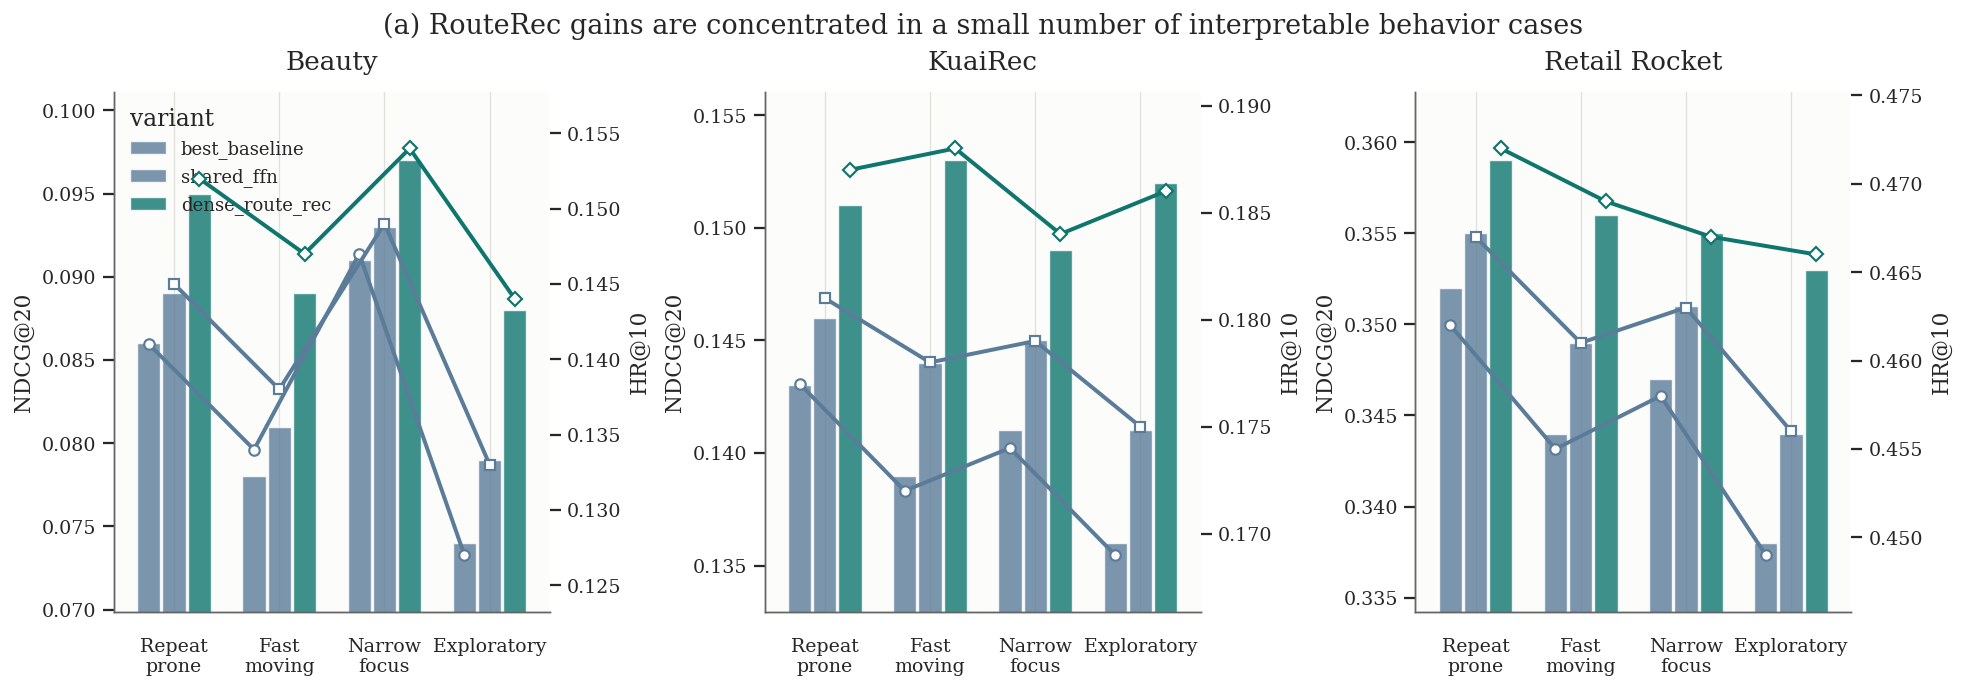

In [2]:
display(Markdown('### (a) Per-case quality with only the essential comparators'))
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.9), constrained_layout=True)
for axis, dataset in zip(axes, datasets):
    subset = plot_quality_df[
        (plot_quality_df['dataset'] == dataset)
        & (plot_quality_df['variant'].isin(variant_order))
    ].copy()
    dual_metric_grouped_plot(
        subset,
        category_col='slice_name',
        variant_col='variant',
        bar_col='ndcg20',
        line_col='hr10',
        ax=axis,
        title=dataset,
        bar_label='NDCG@20',
        line_label='HR@10',
        category_order=case_order,
        category_labels=case_label_map,
        variant_order=variant_order,
        rotate=0,
        show_legend=(dataset == datasets[0]),
        single_variant_category_colors=False,
    )
    axis.tick_params(axis='x', pad=8)
fig.suptitle('(a) RouteRec gains are concentrated in a small number of interpretable behavior cases', y=1.05, fontsize=15)
plt.show()

### (b) Gain is easier to interpret once it is tied to routing behavior

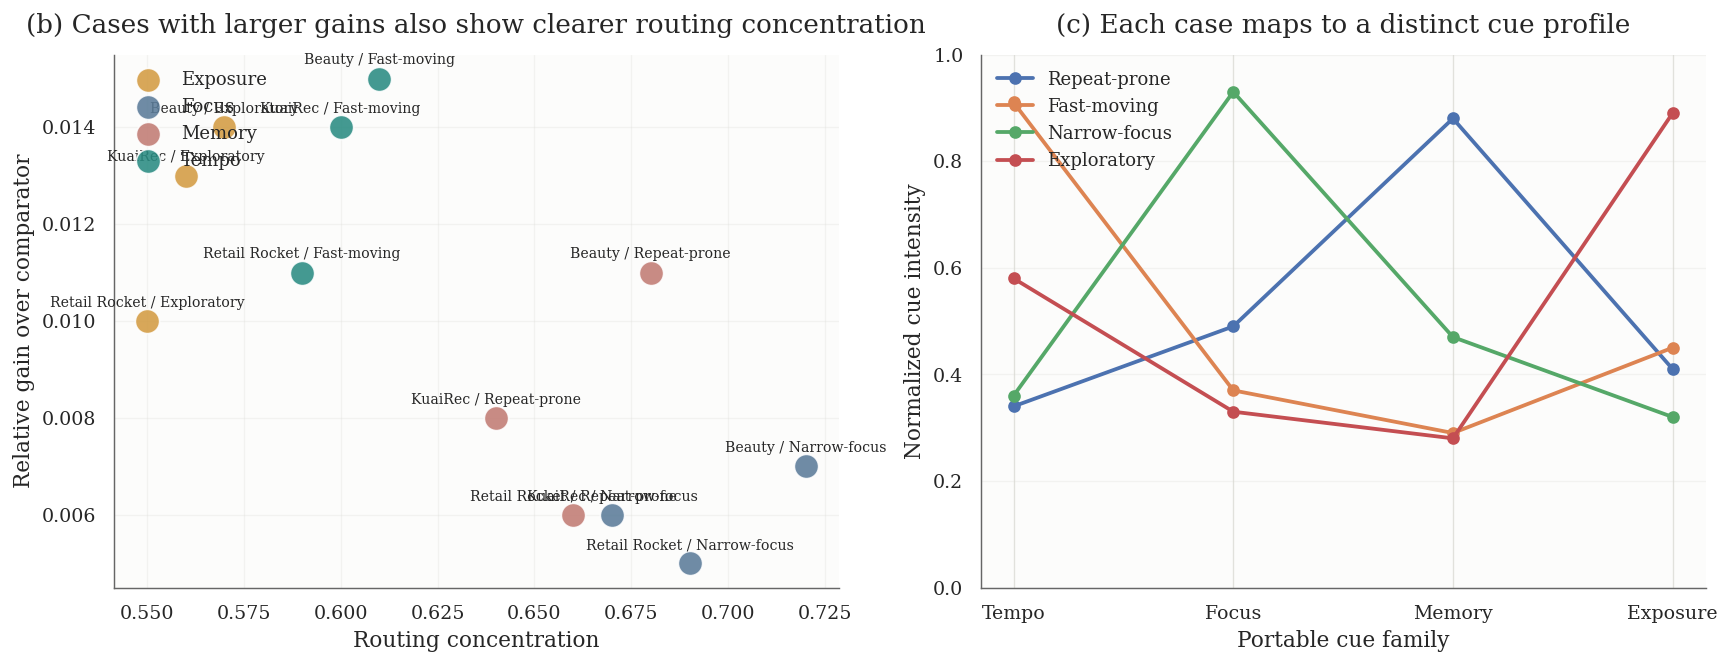

In [3]:
display(Markdown('### (b) Gain is easier to interpret once it is tied to routing behavior'))
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), constrained_layout=True)
scatter_ax, profile_ax = axes

for family, subset in slice_alignment_df.groupby('dominant_family'):
    scatter_ax.scatter(
        subset['route_concentration'],
        subset['relative_gain'],
        s=180,
        color=family_colors[family],
        edgecolor='white',
        linewidth=0.9,
        alpha=0.88,
        label=family,
    )
    for row in subset.itertuples():
        scatter_ax.annotate(f'{row.dataset} / {row.slice_name}', (row.route_concentration, row.relative_gain), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7.8)
scatter_ax.set_xlabel('Routing concentration')
scatter_ax.set_ylabel('Relative gain over comparator')
scatter_ax.set_title('(b) Cases with larger gains also show clearer routing concentration')
scatter_ax.grid(alpha=0.25)
scatter_ax.legend(frameon=False, loc='upper left')

for case_name in case_order:
    subset = slice_profile_df[slice_profile_df['slice_name'] == case_name].set_index('family').loc[family_order].reset_index()
    profile_ax.plot(
        family_order,
        subset['value'],
        marker='o',
        linewidth=2.1,
        label=case_name,
    )
profile_ax.set_ylim(0, 1.0)
profile_ax.set_ylabel('Normalized cue intensity')
profile_ax.set_xlabel('Portable cue family')
profile_ax.set_title('(c) Each case maps to a distinct cue profile')
profile_ax.grid(axis='y', alpha=0.25)
profile_ax.legend(frameon=False, loc='upper left')
plt.show()